# 🏛️ Curso de Análisis No Lineal de Estructuras
## Análisis Estático No Lineal (Pushover) con Masas, Cargas Nodales y Método N2
**Profesor:** Orlando Arroyo | **Entorno:** Google Colab / Jupyter Notebook

Este notebook implementa el modelado numérico y análisis no lineal estático (Pushover) de un pórtico 2D de concreto reforzado con:
- Modelos constitutivos no lineales para concreto (confinado y no confinado con regularización) y acero con pandeo (Dhakal-Maekawa).
- Secciones de fibra discretizadas para vigas y columnas.
- Diafragmas de piso rígidos y eliminación de nodos no conectados.
- Cargas distribuidas gravitacionales y asignación de masas nodales.
- Análisis modal de valores propios y extracción de propiedades para normalización del **Método N2** (Fajfar, 2000).
- Análisis de gravedad y Pushover controlado por desplazamiento lateral.
- Post-procesamiento didáctico: curva de capacidad ($V_b$ vs $\Delta_{techo}$) y perfil de derivas de entrepiso.

### 📦 Paso 1: Instalación de Dependencias
En Google Colab, ejecutamos el siguiente bloque para instalar automáticamente OpenSeesPy, `opseestools` y herramientas de visualización.

In [1]:
# Instalación de paquetes necesarios en Colab
!pip install -q openseespy opseestools opsvis matplotlib numpy pandas scipy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### 📚 Paso 2: Importación de Librerías y Configuración Gráfica

In [13]:
from openseespy.opensees import *
import matplotlib.pyplot as plt
import opseestools.analisis as an
import opseestools.utilidades as ut
import opsvis as opsv
import numpy as np
import pandas as pd
import itertools

# Configuración de visualización
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("default")
print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


### 📐 Paso 3: Inicialización del Modelo y Geometría
- **Unidades de Trabajo:**
  - Longitud: $[m]$
  - Fuerza: $[kN]$
  - Esfuerzo: $[MPa]$ (en OpenSees $kPa = kN/m^2$)
  - Masa: $[ton] = [kN\cdot s^2/m]$
  - Aceleración: $[m/s^2]$ ($g = 9.81\,m/s^2$)

In [14]:
wipe()
model("basic", "-ndm", 2, "-ndf", 3)

# Coordenadas de los ejes y pisos
coordx = [0.0, 5.0, 12.0, 18.0]        # Posiciones en X [m]
coordy = [3.0 * i for i in range(8)]    # 7 pisos de 3 m cada uno [m]

# Generación de malla nodal y apoyos empotrados en la base
ut.creategrid(coordx, coordy)
fixY(0.0, 1, 1, 1)

print(f"Modelo inicializado: {len(coordx)} ejes verticales, {len(coordy)} niveles horizontales (H = {coordy[-1]} m).")

Modelo inicializado: 4 ejes verticales, 8 niveles horizontales (H = 21.0 m).


### 🧱 Paso 4: Definición de Materiales No Lineales
Definimos los modelos constitutivos de concreto no confinado, confinado (Mander con regularización de energía de fractura) y acero de refuerzo con efecto de pandeo (Dhakal & Maekawa).

In [15]:
fc = 28   # Resistencia a la compresión del concreto [MPa]
fy = 420  # Límite de fluencia del acero de refuerzo [MPa]

# Detallado DMO (Disipación Moderada de Energía)
tag_noconf, tag_conf, tag_acero = ut.col_materials(fc, fy, detailing="DMO", nps=3)
print(f"Materiales asignados -> Concreto no confinado: {tag_noconf}, Confinado: {tag_conf}, Acero: {tag_acero}")

Materiales asignados -> Concreto no confinado: 102, Confinado: 101, Acero: 100


### 📏 Paso 5: Creación de Secciones de Concreto Reforzado
Modelado de secciones rectangulares discretizadas en fibras (`create_rect_RC_section`), con armadura longitudinal superior, inferior y piel.

In [16]:
# Dimensiones de secciones [m]
Bcol, Hcol   = 0.55, 0.55
Bcol2, Hcol2 = 0.60, 0.60
Bvig, Hvig   = 0.45, 0.50
Bvig2, Hvig2 = 0.45, 0.60
c = 0.05  # Recubrimiento al centro de la barra [m]

# Áreas nominales de barras [m^2]
As4 = 0.000127 # #4
As5 = 0.000200 # #5
As6 = 0.000280 # #6
As7 = 0.003870 # #7
As8 = 0.000508 # #8

# Tags de sección
col55x55 = 101
col60x60 = 102
vig45x50 = 201
vig45x60 = 202

# Construcción de secciones de fibra
ut.create_rect_RC_section(col55x55, Hcol, Bcol, c, tag_conf, tag_noconf, tag_acero, 5, As8, 5, As8, 6, As8)
ut.create_rect_RC_section(vig45x50, Hvig, Bvig, c, tag_conf, tag_noconf, tag_acero, 9, As6, 5, As4)
ut.create_rect_RC_section(col60x60, Hcol2, Bcol2, c, tag_conf, tag_noconf, tag_acero, 5, As8, 5, As8, 6, As8)
ut.create_rect_RC_section(vig45x60, Hvig2, Bvig2, c, tag_conf, tag_noconf, tag_acero, 9, As6, 5, As4)
print("Secciones transversales de fibra definidas correctamente.")

Secciones transversales de fibra definidas correctamente.


### 🏢 Paso 6: Elementos Viga-Columna y Diafragmas Rígidos
Asignamos las secciones por niveles, permitiendo retranqueos y vanos vacíos mediante `None`.

In [17]:
# Columnas por nivel (Pisos 1 a 7)
columns_floor1 = [col55x55, col60x60, col60x60, col55x55]
columns_floor2 = [col55x55, col60x60, col60x60, col55x55]
columns_floor3 = [col55x55, col60x60, col60x60, col55x55]
columns_floor4 = [col55x55, col55x55, col55x55, col55x55]
columns_floor5 = [col55x55, col55x55, col55x55, col55x55]
columns_floor6 = [col55x55, col55x55, col55x55, col55x55]
columns_floor7 = ["None", col55x55, col55x55, "None"]

building_columns = [
    columns_floor1, columns_floor2, columns_floor3,
    columns_floor4, columns_floor5, columns_floor6, columns_floor7
]

# Vigas por nivel (Pisos 1 a 7)
beams_floor1 = [vig45x50, vig45x60, vig45x60]
beams_floor2 = [vig45x50, vig45x60, vig45x60]
beams_floor3 = [vig45x50, vig45x60, vig45x60]
beams_floor4 = [vig45x50, vig45x60, vig45x60]
beams_floor5 = [vig45x50, "None", vig45x50]
beams_floor6 = [vig45x50, vig45x50, vig45x50]
beams_floor7 = ["None", vig45x50, "None"]

building_beams = [
    beams_floor1, beams_floor2, beams_floor3,
    beams_floor4, beams_floor5, beams_floor6, beams_floor7
]

# Creación de elementos basados en fuerzas
tagcols, tagbeams, column_info, beam_info = ut.create_elements2(
    coordx, coordy, building_columns, building_beams, output=0
)
ut.remove_hanging_nodes(tagcols, tagbeams)

# Diafragmas rígidos (1 = activo, 0 = inactivo)
floor_diaphragms = [1, 1, 1, 1, 0, 1, 0]
ut.apply_diaphragms(floor_diaphragms, output=0)
print(f"Estructura ensamblada: {len(tagcols)} columnas y {len(tagbeams)} vigas activas.")

Creating diaphragm for floor:  1
Creating diaphragm for floor:  2
Creating diaphragm for floor:  3
Creating diaphragm for floor:  4
Creating diaphragm for floor:  6
Estructura ensamblada: 26 columnas y 18 vigas activas.


### ⚖️ Paso 7: Cargas Gravitacionales en Vigas
Cargas distribuidas verticales $[kN/m]$ aplicadas a las vigas del pórtico.

In [18]:
beam_loads = [
    [-70, -70, -70], # Piso 1
    [-70, -70, -70], # Piso 2
    [-70, -70, -70], # Piso 3
    [-70, -70, -70], # Piso 4
    [-70, -70],      # Piso 5
    [-70, -70, -70], # Piso 6
    [-50]            # Techo (Piso 7)
]

ut.load_beams2(beam_loads, tagbeams, output=0)
print("Cargas gravitacionales uniformemente distribuidas asignadas a las vigas.")

number matches, creating loads
Cargas gravitacionales uniformemente distribuidas asignadas a las vigas.


### 🏋️ Paso 8: Asignación de Masas Nodales
> **Importante para estudiantes:** OpenSees requiere masa para formular la matriz $[M]$ y realizar el análisis de valores propios (`eigen`), que es la base para calcular el factor de participación modal $\Gamma_1$ en el **Método N2**.
>
> La masa se introduce en toneladas métricas $[ton] = [kN\cdot s^2/m]$.

In [8]:
nodes_tags_updated = np.array(getNodeTags())
coordx_updated = np.array([nodeCoord(int(i))[0] for i in nodes_tags_updated])
coordy_updated = np.array([nodeCoord(int(i))[1] for i in nodes_tags_updated])

# Masa por defecto por nodo elevado (y > 0)
# Los estudiantes pueden ajustar este valor o asignar masas piso a piso
default_mass = 20.0 # [ton]

for tag, y in zip(nodes_tags_updated, coordy_updated):
    if y > 0: # Superestructura
        mass(int(tag), default_mass, default_mass, 0.0)

# Mostrar resumen tabular
df_masas = pd.DataFrame({
    "Nodo": nodes_tags_updated,
    "Coord X [m]": coordx_updated,
    "Coord Y [m]": coordy_updated,
    "Masa [ton]": [default_mass if y > 0 else 0.0 for y in coordy_updated]
})
print(f"✅ Masas de {default_mass} ton asignadas a nodos elevados.")
df_masas.head(10)

✅ Masas de 20.0 ton asignadas a nodos elevados.


,Nodo,Coord X [m],Coord Y [m],Masa [ton]
0,1000,0.0,0.0,0.0
1,1001,0.0,3.0,20.0
2,1002,0.0,6.0,20.0
3,1003,0.0,9.0,20.0
4,1004,0.0,12.0,20.0
5,1005,0.0,15.0,20.0
6,1006,0.0,18.0,20.0
7,2000,5.0,0.0,0.0
8,2001,5.0,3.0,20.0
9,2002,5.0,6.0,20.0


### 🎯 Paso 9: Análisis Modal y Parámetros del Método N2
Calculamos los modos de vibración, periodos naturales y factores de participación modal.

In [9]:
num_modes = len(coordy) - 1
w2 = eigen(num_modes)
modal_props = modalProperties("-print", "-unorm", "-return")

periods = modal_props.get("eigenPeriod", [2*np.pi/np.sqrt(v) for v in w2])
print("="*50)
print("RESULTADOS DEL ANÁLISIS MODAL:")
print("="*50)
for i in range(min(4, len(periods))):
    print(f"Modo {i+1}: Periodo T = {periods[i]:.4f} s | Frecuencia f = {1.0/periods[i]:.3f} Hz")
print("="*50)

RESULTADOS DEL ANÁLISIS MODAL:
Modo 1: Periodo T = 0.7400 s | Frecuencia f = 1.351 Hz
Modo 2: Periodo T = 0.2587 s | Frecuencia f = 3.866 Hz
Modo 3: Periodo T = 0.1465 s | Frecuencia f = 6.827 Hz
Modo 4: Periodo T = 0.1035 s | Frecuencia f = 9.666 Hz


Using DomainModalProperties - Developed by: Massimo Petracca, Guido Camata, ASDEA Software Technology


### 🌍 Paso 10: Análisis de Gravedad y Visualización del Modelo

✅ Cargas de gravedad aplicadas con éxito.


<Figure size 700x600 with 0 Axes>

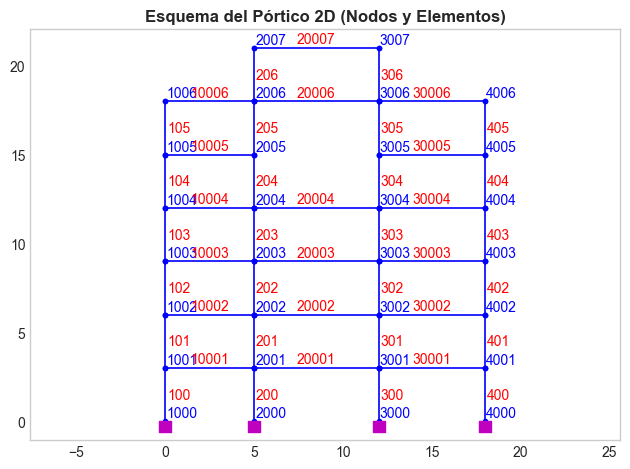

In [10]:
an.gravedad()
loadConst("-time", 0.0)
print("✅ Cargas de gravedad aplicadas con éxito.")

# Gráfica del modelo estructural con opsvis
plt.figure(figsize=(7, 6))
opsv.plot_model(node_labels=1, element_labels=1, gauss_points=False)
plt.title("Esquema del Pórtico 2D (Nodos y Elementos)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 🚀 Paso 11: Ejecución del Análisis Pushover No Lineal
Aplicamos un patrón de cargas laterales invariante proporcional al primer modo de vibración o triangular inverso y empujamos la estructura hasta alcanzar un desplazamiento objetivo del 5% de la altura total.

Empujando el pórtico hasta Dmax = 1.050 m con control en nodo 4006...
configuración por defecto no converge en desplazamiento:  0.3092578463561256
Pushover analisis fallido
Desplazamiento alcanzado:  0.3092578463561256 m
Análisis Pushover finalizado. D_máx = 0.3093 m | Vb_máx = 1535.70 kN


WARNING - ForceBeamColumn2d::update - failed to get compatible element forces & deformations for element: 30003(dW: << -0.000316421)
Domain::update - domain failed in update
DisplacementControl::update - model failed to update for new dU
WARNING NewtonRaphson::solveCurrentStep() -the Integrator failed in update()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1445.68
OpenSees > analyze failed, returned: -3 error flag
WARNING - ForceBeamColumn2d::update - failed to get compatible element forces & deformations for element: 30003(dW: << -0.000316566)
Domain::update - domain failed in update
DisplacementControl::update - model failed to update for new dU
WARNING AcceleratedNewton::solveCurrentStep() -the Integrator failed in update()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1445.71
OpenSees > analyze failed, returned: -3 error flag
WARNING - ForceBeamColumn2d::update - failed to get compatible element for

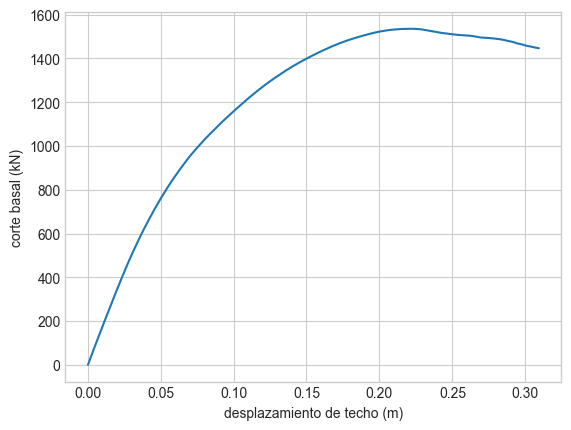

In [11]:
leftmost_nodes = ut.find_leftmost_nodes(coordy)
ut.pushover_loads(coordy, nodes=leftmost_nodes)
elements = tagcols + tagbeams
nodes_control = [1000] + [int(i) for i in leftmost_nodes]

H_total = coordy[-1]
Dmax = 0.05 * H_total  # Desplazamiento objetivo: 5% de H
Dincr = 0.001          # Incremento por paso [m]
ctrl_node = getNodeTags()[-1] # Nodo de control (techo)

print(f"Empujando el pórtico hasta Dmax = {Dmax:.3f} m con control en nodo {ctrl_node}...")
dtecho, Vbasal, drifts, rotations = an.pushover2DRot(
    Dmax, Dincr, ctrl_node, 1, nodes_control, elements
)

# Extracción de resultados
story_drifts = drifts[:len(dtecho), :]
col_rotations = rotations[:len(tagcols), :len(dtecho), [1, 2]]
beam_rotations = rotations[len(tagcols):, :len(dtecho), [1, 2]]

d_max_alcanzado = dtecho[-1] if len(dtecho) > 0 else 0
v_max_alcanzado = max(Vbasal) if len(Vbasal) > 0 else 0
print(f"Análisis Pushover finalizado. D_máx = {d_max_alcanzado:.4f} m | Vb_máx = {v_max_alcanzado:.2f} kN")

### 📊 Paso 12: Gráficas de Resultados para Discusión en Clase
1. **Curva de Capacidad Pushover:** Cortante basal $V_b$ vs. Desplazamiento en el techo $\Delta_{techo}$.
2. **Perfil de Derivas de Entrepiso:** Evolución de la deriva a lo largo de la altura del edificio.

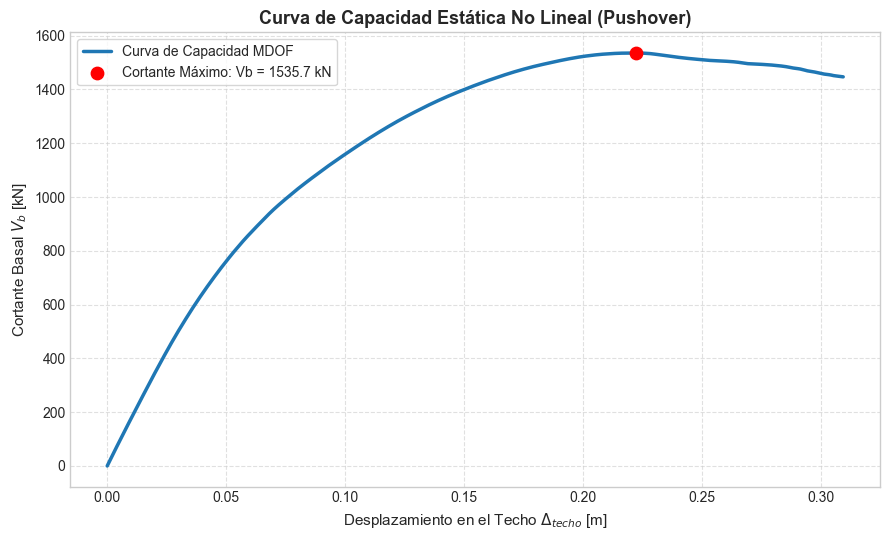

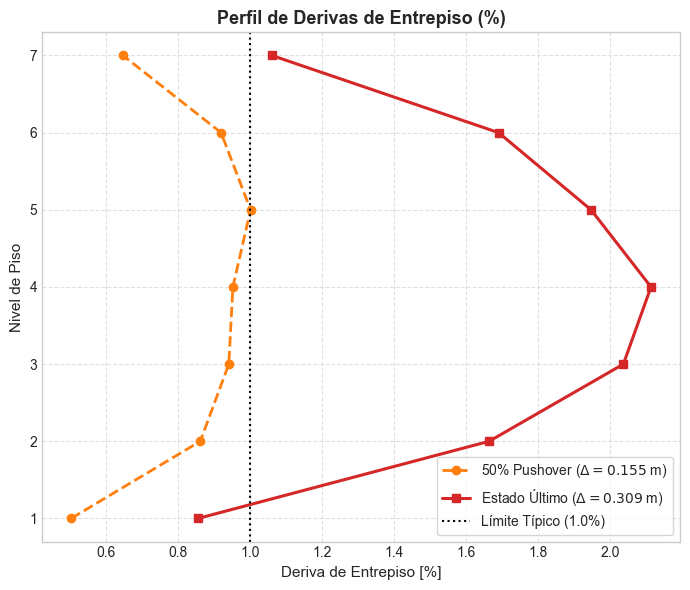

In [12]:
# 1. Curva de Capacidad Pushover
plt.figure(figsize=(9, 5.5))
plt.plot(dtecho, Vbasal, color="#1f77b4", linewidth=2.5, label="Curva de Capacidad MDOF")
plt.scatter([dtecho[np.argmax(Vbasal)]], [v_max_alcanzado], color="red", s=80, zorder=5, 
            label=f"Cortante Máximo: Vb = {v_max_alcanzado:.1f} kN")
plt.title("Curva de Capacidad Estática No Lineal (Pushover)", fontsize=13, fontweight="bold")
plt.xlabel(r"Desplazamiento en el Techo $\Delta_{techo}$ [m]", fontsize=11)
plt.ylabel(r"Cortante Basal $V_b$ [kN]", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True, facecolor="white", fontsize=10)
plt.tight_layout()
plt.show()

# 2. Perfil de Derivas de Entrepiso
if story_drifts.shape[1] > 0:
    plt.figure(figsize=(7, 6))
    num_floors = story_drifts.shape[1]
    floors = list(range(1, num_floors + 1))
    idx_50 = len(dtecho) // 2
    
    plt.plot(story_drifts[idx_50, :] * 100, floors, "o--", color="#ff7f0e", linewidth=2, 
             label=rf"50% Pushover ($\Delta = {dtecho[idx_50]:.3f}$ m)")
    plt.plot(story_drifts[-1, :] * 100, floors, "s-", color="#d62728", linewidth=2.2, 
             label=rf"Estado Último ($\Delta = {dtecho[-1]:.3f}$ m)")
    plt.axvline(1.0, color="black", linestyle=":", linewidth=1.5, label="Límite Típico (1.0%)")
    
    plt.title("Perfil de Derivas de Entrepiso (%)", fontsize=13, fontweight="bold")
    plt.xlabel("Deriva de Entrepiso [%]", fontsize=11)
    plt.ylabel("Nivel de Piso", fontsize=11)
    plt.yticks(floors)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(frameon=True, facecolor="white", fontsize=10)
    plt.tight_layout()
    plt.show()